In [ ]:
# !pip install factor_analyzer

In [11]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

/opt/anaconda3/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


Bartlett's P-Value: 0.0
KMO Overall: 0.8844703873677031


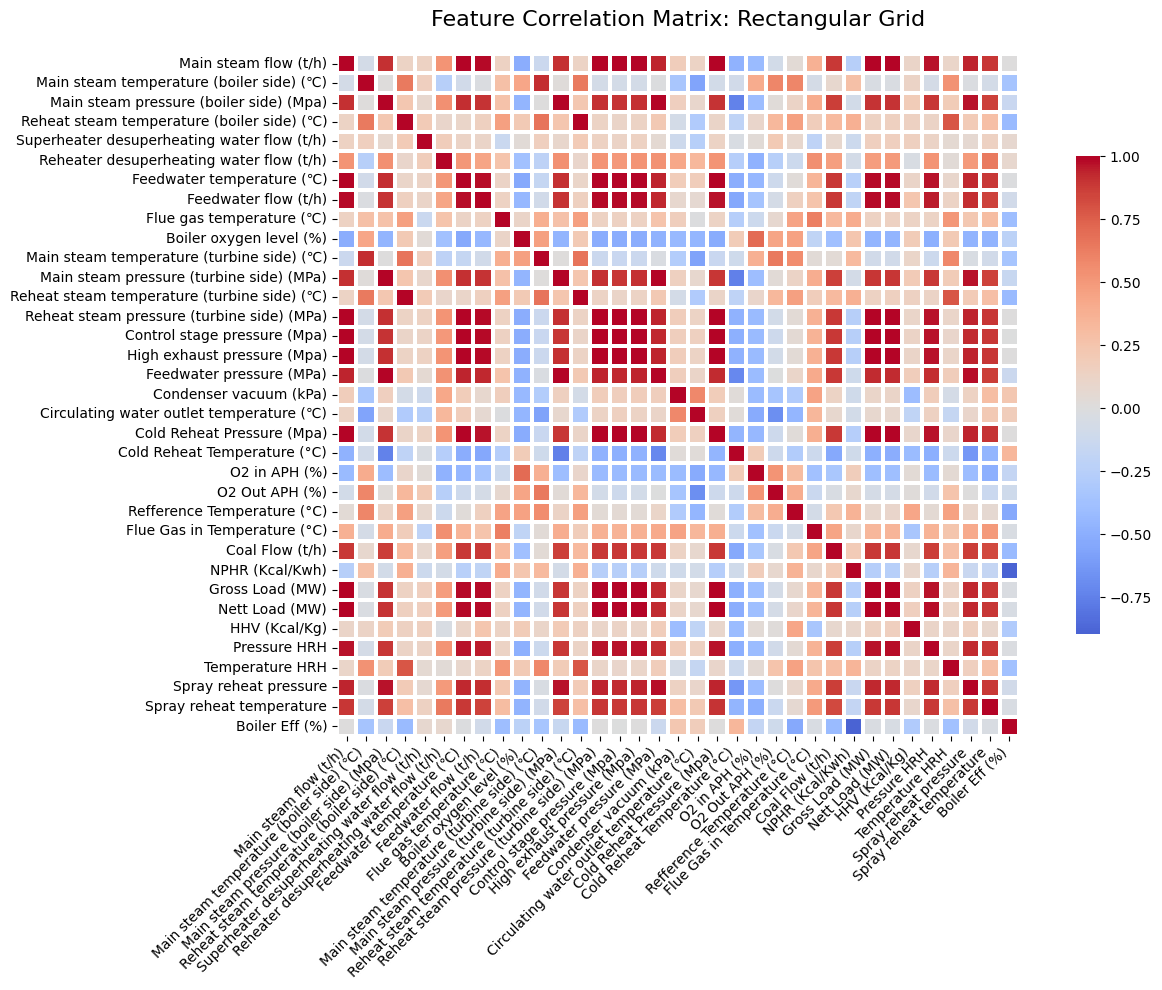

In [12]:
# Select only numeric columns to avoid processing text/IDs
# 1. Select only numeric data
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Convert to numpy array to bypass the library compatibility error
data_array = numeric_df.values

# 2. Calculate the Correlation Matrix manually
corr_matrix = numeric_df.corr()

# Re-run Factor Suitability (KMO & Bartlett)
chi_square_value, p_value = calculate_bartlett_sphericity(data_array)
kmo_all, kmo_model = calculate_kmo(data_array)
print(f"Bartlett's P-Value: {p_value}")
print(f"KMO Overall: {kmo_model}")

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the visual style and figure size
plt.figure(figsize=(14, 10))

# 2. Generate the Rectangle Box Heatmap
# We remove 'mask' to show the full rectangle box
sns.heatmap(corr_matrix, 
            annot=False,          # Show the correlation coefficients
            fmt=".2f",           # Format to 2 decimal places
            cmap='coolwarm',       # Red-Blue palette (Standard for EFA)
            center=0,            # 0 is the neutral white color
            square=True,         # Ensures each cell is a perfect square
            linewidths=1.5,      # Thickens the "box" borders
            linecolor='white',   # Adds white borders to create distinct boxes
            cbar_kws={"shrink": .7})

# 3. Add labels and title
plt.title('Feature Correlation Matrix: Rectangular Grid', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rotates labels for better readability
plt.yticks(rotation=0)

plt.tight_layout() #

KMO (0.88) and Bartlett’s Test (p=0.0) are both excellent, data is highly suitable for factor analysis. The warning you received about the "Moore-Penrose generalized matrix inversion" indicates that some of variables are very highly correlated (near-perfect multicollinearity), which is exactly what EFA is meant to resolve by grouping them into factors.

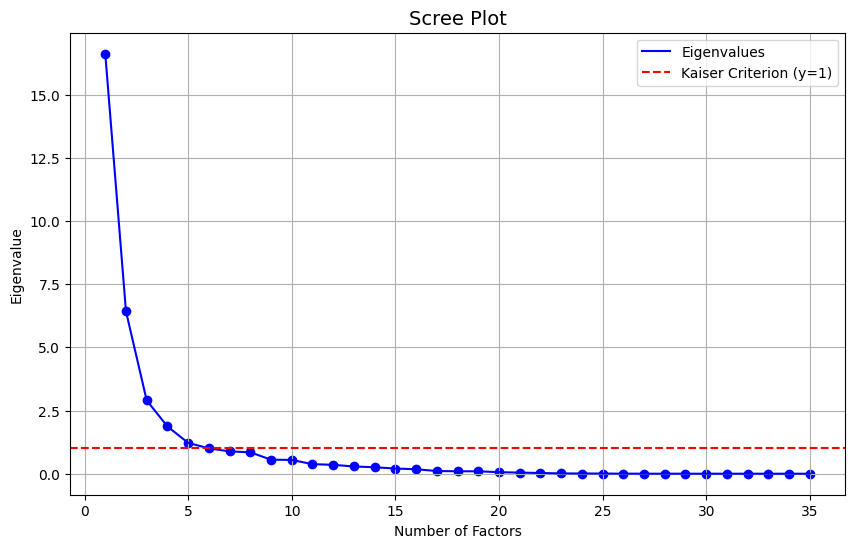

Number of factors with Eigenvalue > 1: 6
Eigenvalues List: [16.621, 6.427, 2.902, 1.872, 1.221, 1.003, 0.885, 0.846, 0.556, 0.546, 0.379, 0.352, 0.287, 0.256, 0.205, 0.176, 0.107, 0.097, 0.096, 0.061, 0.044, 0.028, 0.012, 0.009, 0.007, 0.002, 0.001, 0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0]


In [13]:
# 3. Calculate Eigenvalues manually using Numpy
# This completely bypasses the FactorAnalyzer.fit() bug
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# 4. Sort eigenvalues in descending order
ev_sorted = sorted(eigenvalues, reverse=True)

# 5. Plotting the Scree Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, len(ev_sorted) + 1), ev_sorted, color='blue')
plt.plot(range(1, len(ev_sorted) + 1), ev_sorted, color='blue', label='Eigenvalues')
plt.title('Scree Plot', fontsize=14)
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')

# Kaiser Criterion line (The standard for feature selection)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (y=1)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Count and print eigenvalues > 1
n_factors_recommended = len([i for i in ev_sorted if i > 1])
print(f"Number of factors with Eigenvalue > 1: {n_factors_recommended}")
print("Eigenvalues List:", [round(x, 3) for x in ev_sorted])

In [14]:
# Use the n_factors_recommended from the previous step
n = n_factors_recommended 

# Calculate the Loadings for the top 'n' factors
# We take the first 'n' eigenvectors and scale them by sqrt(eigenvalues)
extracted_loadings = eigenvectors[:, :n] * np.sqrt(ev_sorted[:n])

# Create a clean DataFrame for the Pattern Matrix
pattern_matrix = pd.DataFrame(
    extracted_loadings, 
    index=numeric_df.columns, 
    columns=[f'Factor_{i+1}' for i in range(n)]
)

print("--- Manual Pattern Matrix (Feature Loadings) ---")
print(pattern_matrix.round(3))

--- Manual Pattern Matrix (Feature Loadings) ---
                                             Factor_1  Factor_2  Factor_3  \
Main steam flow (t/h)                          -0.982     0.043     0.120   
Main steam temperature (boiler side) (℃)        0.065    -0.842     0.098   
Main steam pressure (boiler side) (Mpa)        -0.955    -0.108     0.018   
Reheat steam temperature (boiler side) (℃)     -0.193    -0.790    -0.287   
Superheater desuperheating water flow (t/h)    -0.115    -0.169     0.329   
Reheater desuperheating water flow (t/h)       -0.584     0.183    -0.367   
Feedwater temperature (℃)                      -0.980     0.067     0.114   
Feedwater flow (t/h)                           -0.962    -0.041     0.191   
Flue gas temperature (℃)                       -0.235    -0.481    -0.599   
Boiler oxygen level (%)                         0.531    -0.540     0.161   
Main steam temperature (turbine side) (℃)       0.101    -0.863    -0.004   
Main steam pressure (turbin

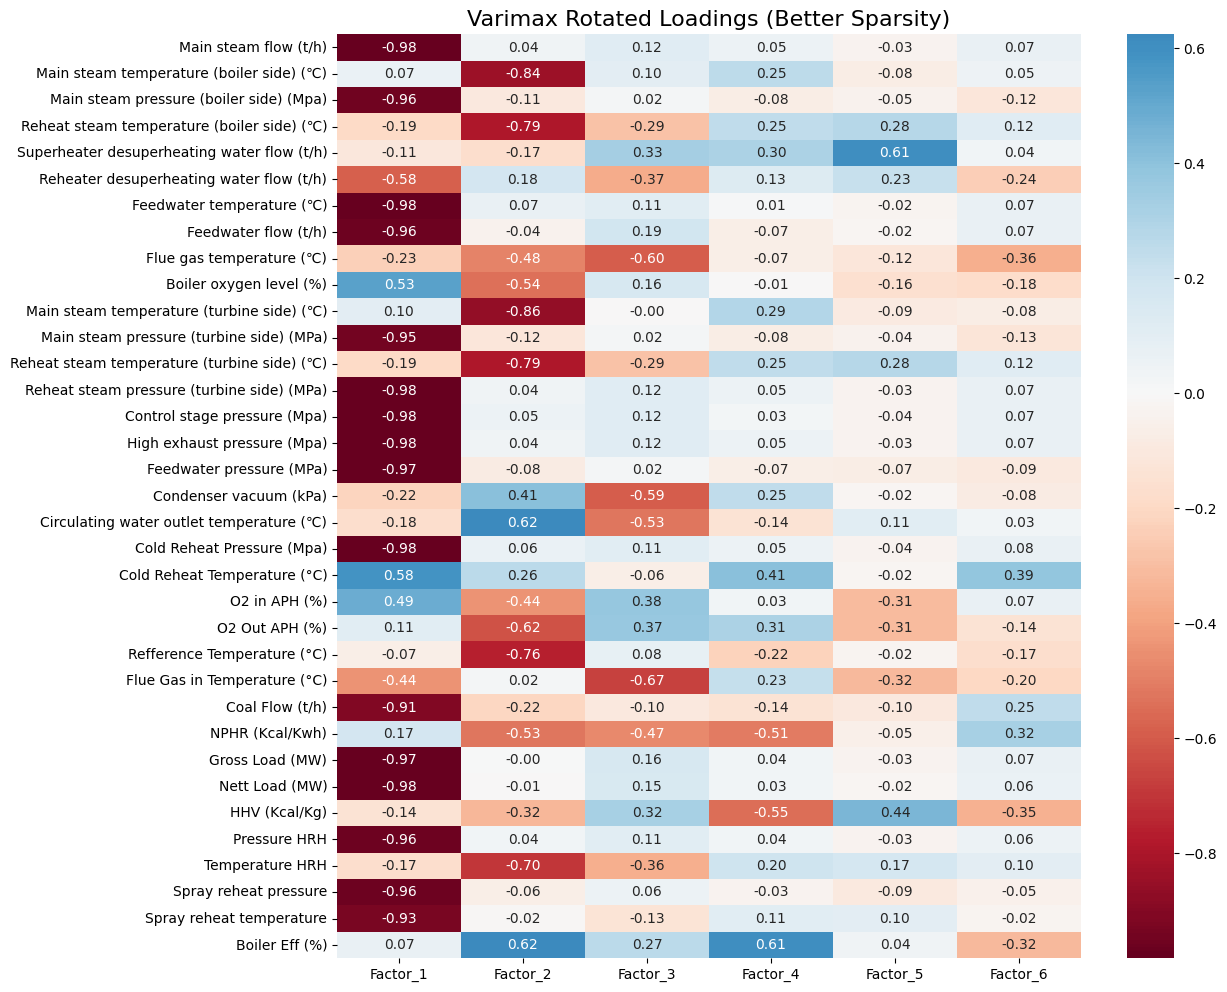

In [15]:
# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
plt.show()

--- Rotated Pattern Matrix (Varimax Orthogonal) ---
                                             Factor_1  Factor_2  Factor_3  \
Main steam flow (t/h)                          -0.987    -0.028    -0.103   
Main steam temperature (boiler side) (℃)        0.015    -0.619     0.637   
Main steam pressure (boiler side) (Mpa)        -0.929    -0.101    -0.063   
Reheat steam temperature (boiler side) (℃)     -0.134    -0.916     0.150   
Superheater desuperheating water flow (t/h)    -0.114    -0.377     0.011   
Reheater desuperheating water flow (t/h)       -0.455    -0.198    -0.507   
Feedwater temperature (℃)                      -0.983    -0.000    -0.130   
Feedwater flow (t/h)                           -0.979    -0.015    -0.026   
Flue gas temperature (℃)                       -0.112    -0.495    -0.033   
Boiler oxygen level (%)                         0.477    -0.184     0.597   
Main steam temperature (turbine side) (℃)       0.078    -0.670     0.610   
Main steam pressure (tur

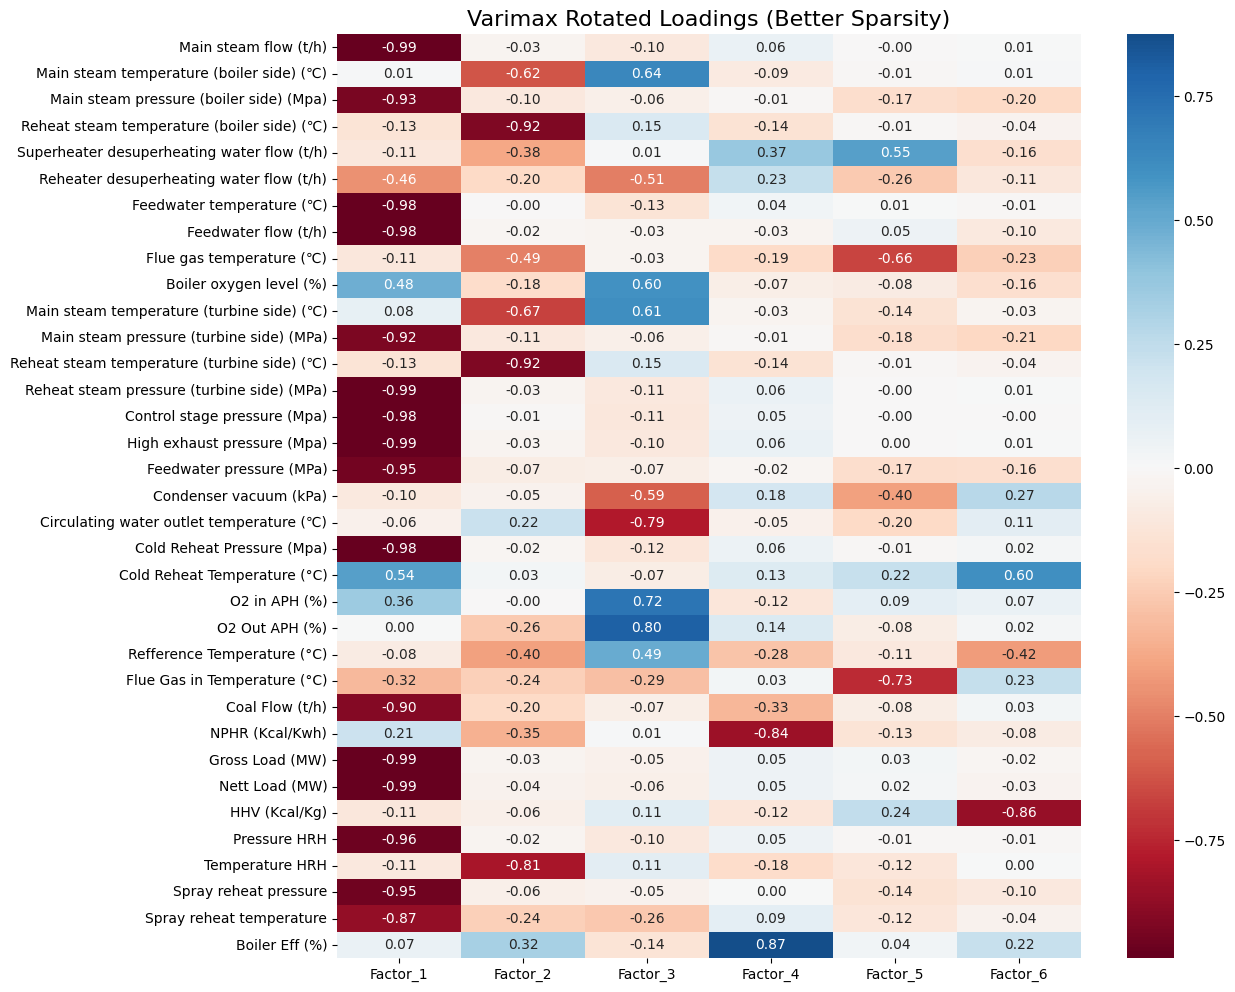

In [16]:
from factor_analyzer import Rotator
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi Rotator Varimax
rotator = Rotator(method='varimax')

# 2. Lakukan Rotasi pada Loading yang sudah diekstrak (n=6)
# extracted_loadings adalah hasil dari langkah sebelumnya (eigenvectors * sqrt(ev))
rotated_loadings = rotator.fit_transform(extracted_loadings)

# 3. Buat Dataframe Pattern Matrix yang sudah Terotasi
rotated_pattern_matrix = pd.DataFrame(
    rotated_loadings,
    index=numeric_df.columns,
    columns=[f'Factor_{i+1}' for i in range(n)]
)

print("--- Rotated Pattern Matrix (Varimax Orthogonal) ---")
print(rotated_pattern_matrix.round(3))

# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(rotated_pattern_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Varimax Rotated Loadings (Better Sparsity)', fontsize=16)
plt.show()


--- Correlation Matrix for Factor_1 (Viral Strain Group) ---
Features: ['Main steam flow (t/h)', 'Main steam pressure (boiler side) (Mpa)', 'Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Main steam pressure (turbine side) (MPa)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)', 'Feedwater pressure (MPa)', 'Cold Reheat Pressure (Mpa)', 'Cold Reheat Temperature (°C)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'Nett Load (MW)', 'Pressure HRH', 'Spray reheat pressure', 'Spray reheat temperature']


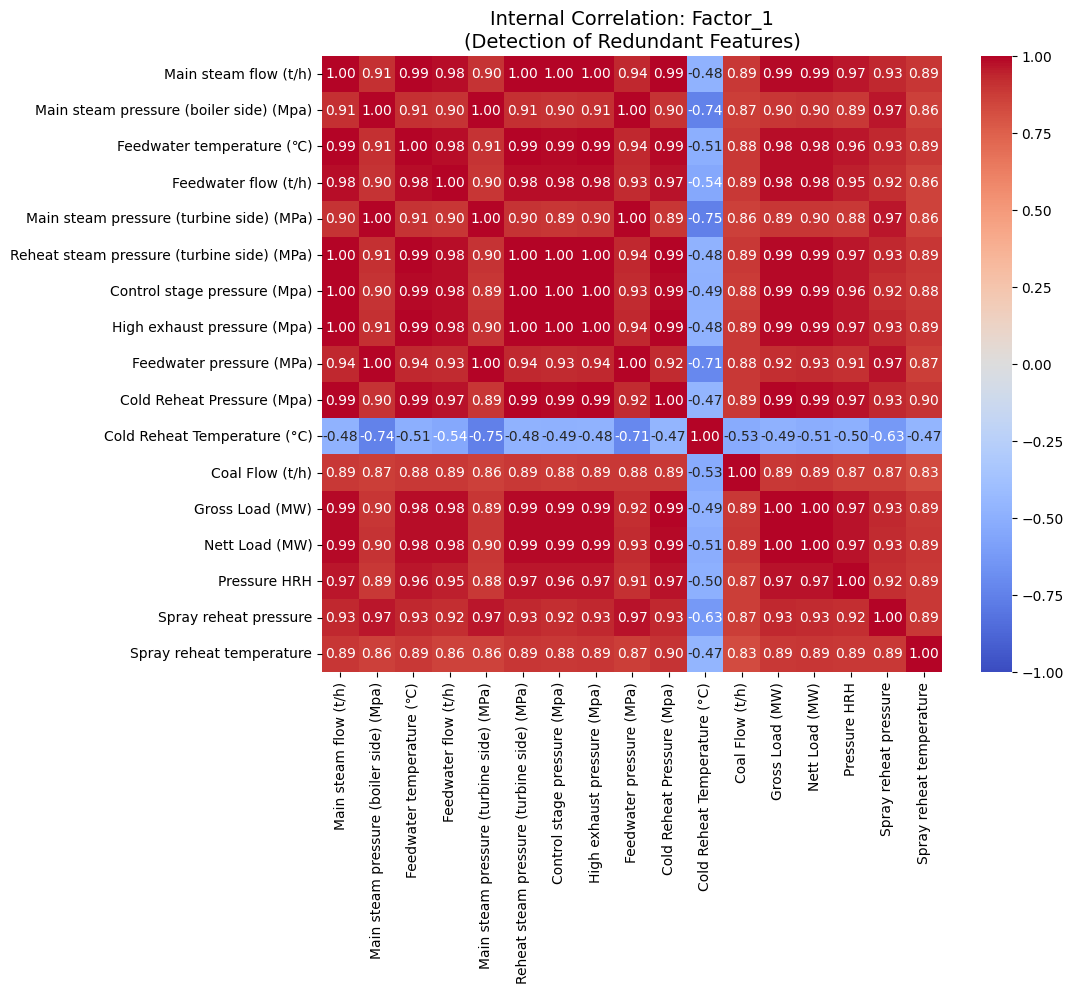


--- Correlation Matrix for Factor_2 (Viral Strain Group) ---
Features: ['Main steam temperature (boiler side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Main steam temperature (turbine side) (℃)', 'Reheat steam temperature (turbine side) (℃)', 'Temperature HRH']


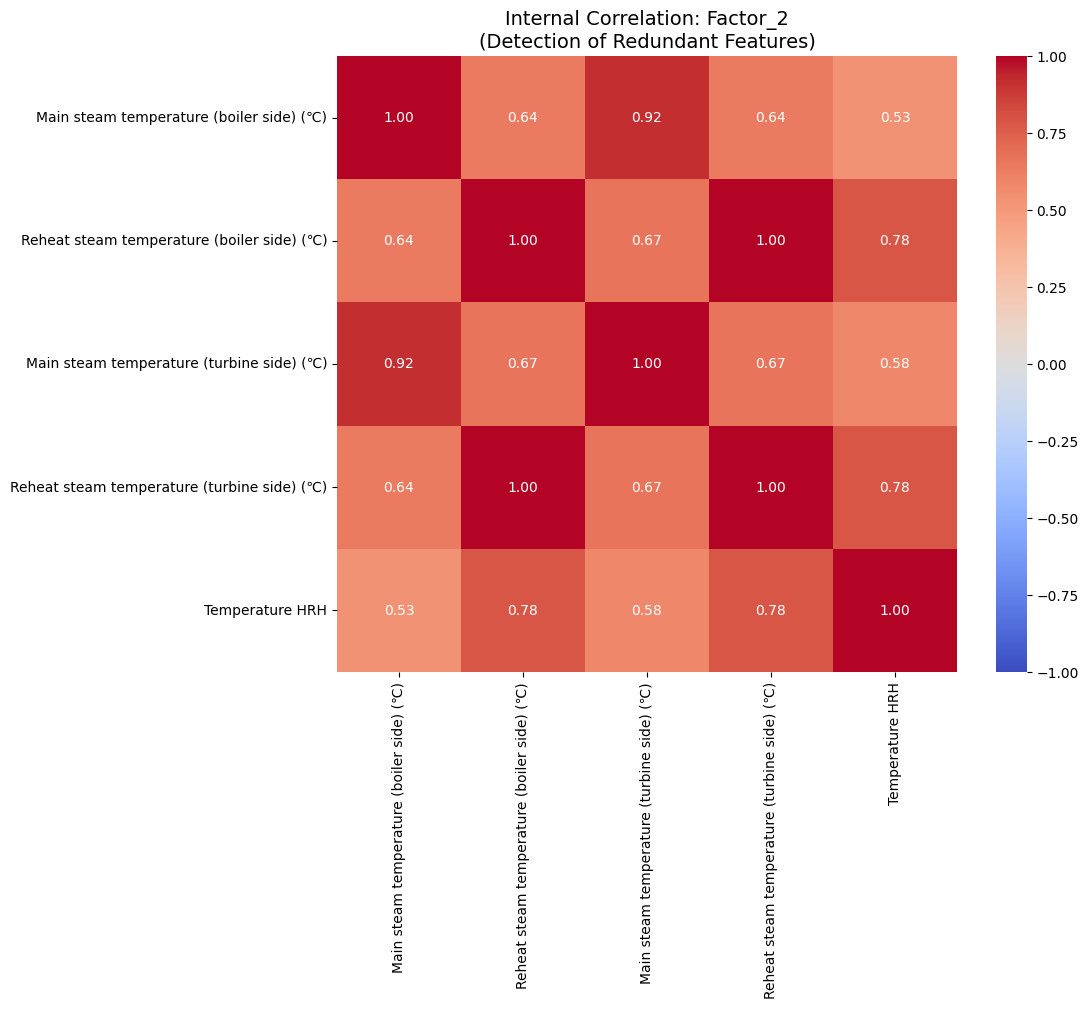


--- Correlation Matrix for Factor_3 (Viral Strain Group) ---
Features: ['Main steam temperature (boiler side) (℃)', 'Reheater desuperheating water flow (t/h)', 'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)', 'Condenser vacuum (kPa)', 'Circulating water outlet temperature (℃)', 'O2 in APH (%)', 'O2 Out APH (%)']


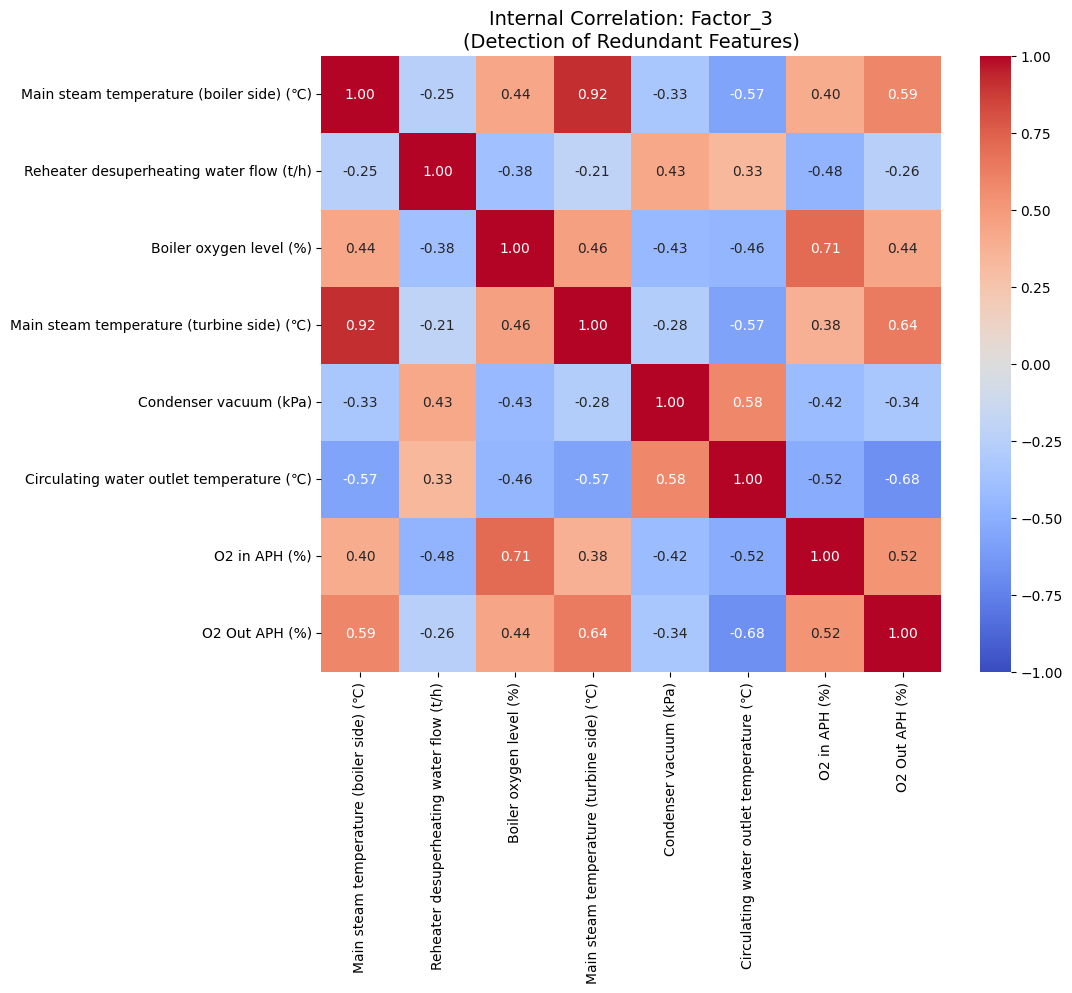


--- Correlation Matrix for Factor_4 (Viral Strain Group) ---
Features: ['NPHR (Kcal/Kwh)', 'Boiler Eff (%)']


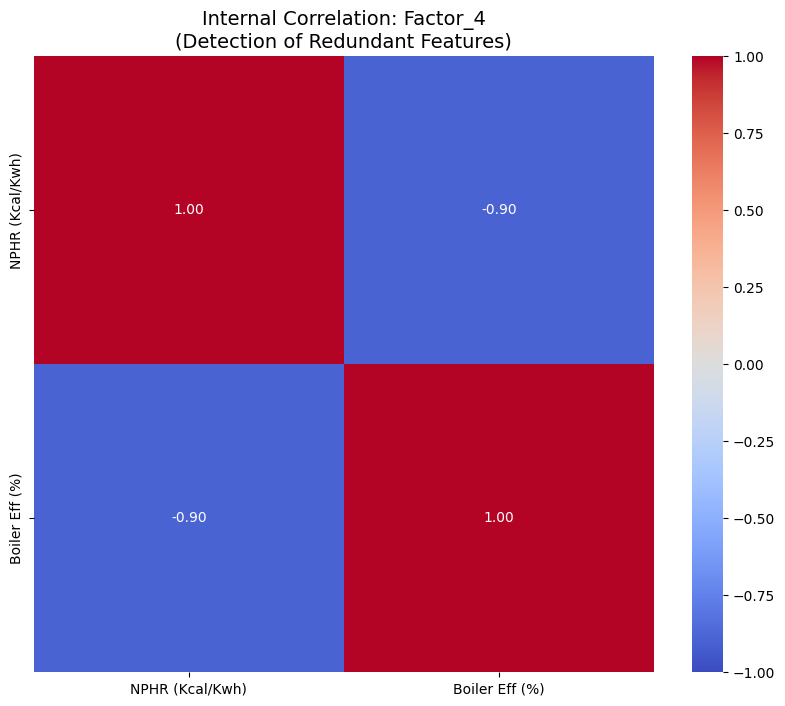


--- Correlation Matrix for Factor_5 (Viral Strain Group) ---
Features: ['Superheater desuperheating water flow (t/h)', 'Flue gas temperature (℃)', 'Flue Gas in Temperature (°C)']


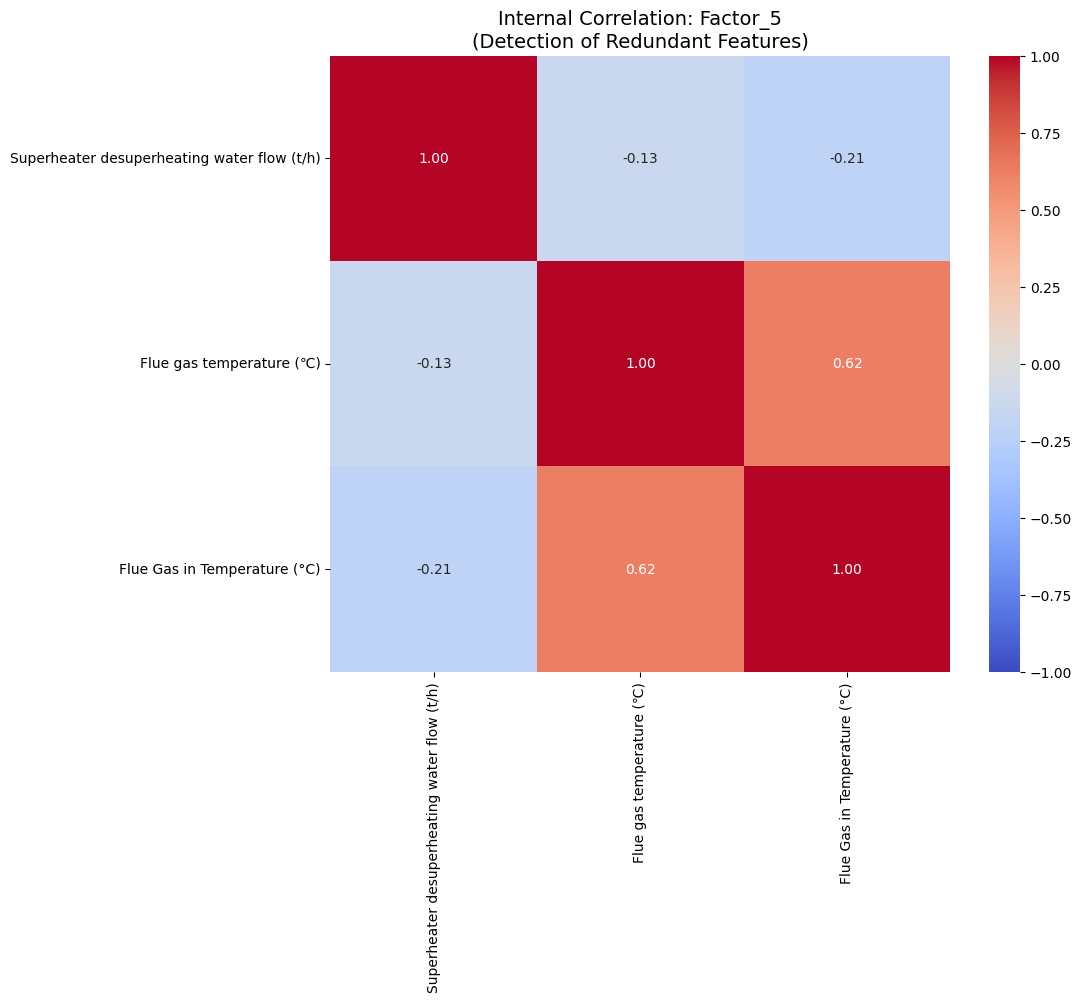


--- Correlation Matrix for Factor_6 (Viral Strain Group) ---
Features: ['Cold Reheat Temperature (°C)', 'HHV (Kcal/Kg)']


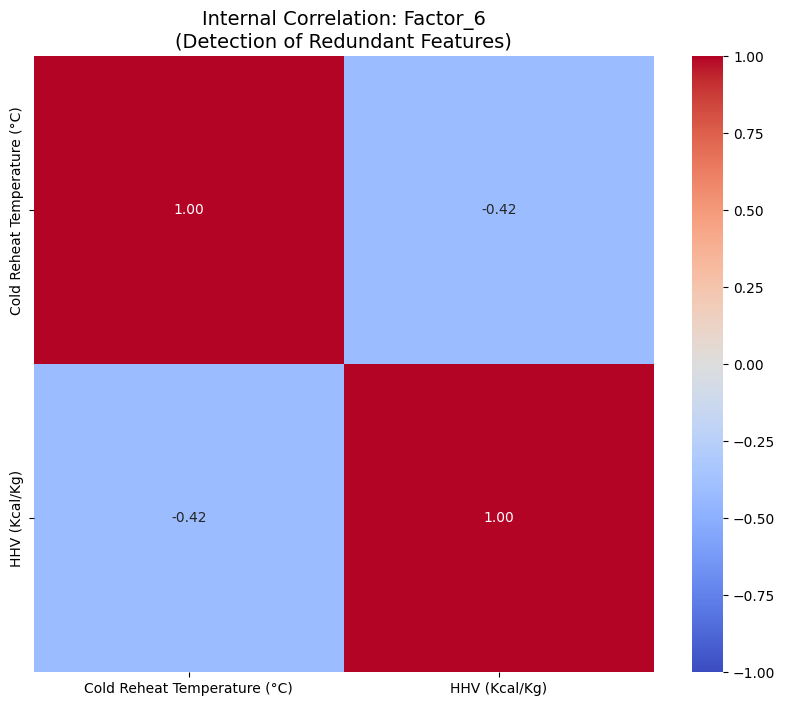

In [17]:
# Tentukan threshold loading (misal: 0.5 untuk menganggap fitur masuk dalam faktor tersebut)
threshold = 0.5

# Loop untuk setiap faktor yang terbentuk (Factor 1 - 6)
for i in range(1, 7):
    factor_name = f'Factor_{i}'
    
    # 1. Identifikasi "Anggota Varian" (Fitur dengan loading tinggi di faktor ini)
    # Kita ambil nilai absolut karena loading negatif tetap menunjukkan hubungan kuat
    factor_features = rotated_pattern_matrix[np.abs(rotated_pattern_matrix[factor_name]) >= threshold].index.tolist()
    
    if len(factor_features) > 1:
        print(f"\n--- Correlation Matrix for {factor_name} (Viral Strain Group) ---")
        print(f"Features: {factor_features}")
        
        # 2. Hitung Matriks Korelasi antar anggota dalam satu faktor
        factor_corr = numeric_df[factor_features].corr()
        
        # 3. Visualisasi untuk deteksi Redundansi (Infection Competition)
        plt.figure(figsize=(10, 8))
        sns.heatmap(factor_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
        plt.title(f'Internal Correlation: {factor_name}\n(Detection of Redundant Features)', fontsize=14)
        plt.show()
    else:
        print(f"\n{factor_name} hanya memiliki satu fitur dominan atau kosong.")

In [18]:
target_col = 'Boiler Eff (%)'
threshold = 0.5
selected_per_factor = {}

for i in range(1, 7):
    factor_name = f'Factor_{i}'
    
    # 1. Ambil anggota fitur dalam faktor tersebut
    factor_features = rotated_pattern_matrix[np.abs(rotated_pattern_matrix[factor_name]) >= threshold].index.tolist()
    
    if target_col in factor_features:
        factor_features.remove(target_col) # Hapus target dari daftar fitur prediktor
    
    if factor_features:
        # 2. Hitung korelasi fitur-fitur tersebut hanya terhadap Target
        target_corr = numeric_df[factor_features].corrwith(numeric_df[target_col]).abs().sort_values(ascending=False)
        
        print(f"\n--- Ranking Correlation to {target_col} in {factor_name} ---")
        print(target_corr)
        
        # Simpan fitur terbaik dari faktor ini
        selected_per_factor[factor_name] = target_corr.index[0]
    else:
        print(f"\n{factor_name} tidak memiliki fitur prediktor di atas threshold.")

print("\n🚀 FINAL SELECTION (Patient Zero per Factor):")
print(selected_per_factor)


--- Ranking Correlation to Boiler Eff (%) in Factor_1 ---
Coal Flow (t/h)                               0.428550
Cold Reheat Temperature (°C)                  0.335263
Main steam pressure (turbine side) (MPa)      0.147938
Main steam pressure (boiler side) (Mpa)       0.141927
Feedwater pressure (MPa)                      0.126976
Feedwater flow (t/h)                          0.094658
Spray reheat pressure                         0.092064
Nett Load (MW)                                0.042987
Spray reheat temperature                      0.034809
Gross Load (MW)                               0.029013
Pressure HRH                                  0.020324
Feedwater temperature (℃)                     0.008826
Reheat steam pressure (turbine side) (MPa)    0.006545
Main steam flow (t/h)                         0.005958
High exhaust pressure (Mpa)                   0.005779
Cold Reheat Pressure (Mpa)                    0.002871
Control stage pressure (Mpa)                  0.002181
dtype:

In [19]:
target_col = 'NPHR (Kcal/Kwh)'
threshold = 0.5
selected_per_factor = {}

for i in range(1, 7):
    factor_name = f'Factor_{i}'
    
    # 1. Ambil anggota fitur dalam faktor tersebut
    factor_features = rotated_pattern_matrix[np.abs(rotated_pattern_matrix[factor_name]) >= threshold].index.tolist()
    
    if target_col in factor_features:
        factor_features.remove(target_col) # Hapus target dari daftar fitur prediktor
    
    if factor_features:
        # 2. Hitung korelasi fitur-fitur tersebut hanya terhadap Target
        target_corr = numeric_df[factor_features].corrwith(numeric_df[target_col]).abs().sort_values(ascending=False)
        
        print(f"\n--- Ranking Correlation to {target_col} in {factor_name} ---")
        print(target_corr)
        
        # Simpan fitur terbaik dari faktor ini
        selected_per_factor[factor_name] = target_corr.index[0]
    else:
        print(f"\n{factor_name} tidak memiliki fitur prediktor di atas threshold.")

print("\n🚀 FINAL SELECTION (Patient Zero per Factor):")
print(selected_per_factor)


--- Ranking Correlation to NPHR (Kcal/Kwh) in Factor_1 ---
Cold Reheat Pressure (Mpa)                    0.266109
Gross Load (MW)                               0.261218
Control stage pressure (Mpa)                  0.257892
Main steam flow (t/h)                         0.254554
High exhaust pressure (Mpa)                   0.254455
Reheat steam pressure (turbine side) (MPa)    0.254233
Nett Load (MW)                                0.254190
Pressure HRH                                  0.253181
Feedwater temperature (℃)                     0.246481
Feedwater flow (t/h)                          0.198605
Coal Flow (t/h)                               0.193531
Spray reheat temperature                      0.174283
Spray reheat pressure                         0.147577
Feedwater pressure (MPa)                      0.107528
Cold Reheat Temperature (°C)                  0.099482
Main steam pressure (boiler side) (Mpa)       0.084926
Main steam pressure (turbine side) (MPa)      0.078157
dtype

In [25]:
import pandas as pd


# Load your dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])
# 2. Definisikan daftar fitur input yang Anda inginkan
selected_inputs = [
    'Coal Flow (t/h)',
    'Reheat steam temperature (boiler side) (℃)',
    'Main steam temperature (boiler side) (℃)',
    'Flue gas temperature (℃)',
    'Cold Reheat Temperature (°C)' 
]

# --- PROSES UNTUK BOILER EFFICIENCY ---
# Mengambil fitur input + Target Boiler
cols_boiler = selected_inputs + ['Boiler Eff (%)']
# Gunakan intersection untuk memastikan kolom benar-benar ada di df
df_boiler_final = df[df.columns.intersection(cols_boiler)].copy()

# Simpan ke Excel
df_boiler_final.to_excel('Rev 3 Selected_Features_Boiler_Efficiency Dataset 1.xlsx', index=False)
print("File 'Rev 3 Selected_Features_Boiler_Efficiency Dataset 1.xlsx' berhasil disimpan.")
import pandas as pd

File 'Rev 3 Selected_Features_Boiler_Efficiency Dataset 1.xlsx' berhasil disimpan.


In [26]:
# Load your dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])
# 2. Definisikan daftar fitur input baru sesuai permintaan Anda
selected_inputs_nphr = [
    'Cold Reheat Pressure (Mpa)',
    'Reheat steam temperature (boiler side) (℃)',
    'Main steam temperature (turbine side) (℃)',
    'Flue gas temperature (℃)',
    'Cold Reheat Temperature (°C)'
    
]

# --- PROSES UNTUK NPHR ---
# Menggabungkan fitur input baru dengan Target NPHR
cols_nphr = selected_inputs_nphr + ['NPHR (Kcal/Kwh)']

# Menggunakan intersection untuk memastikan kolom tersedia di dalam file Excel
df_nphr_final = df[df.columns.intersection(cols_nphr)].copy()

# Simpan ke Excel dengan nama file yang relevan
output_filename = 'Rev 3 Selected_Features_NPHR Dataset 1.xlsx'
df_nphr_final.to_excel(output_filename, index=False)

print(f"File '{output_filename}' berhasil disimpan.")
print(f"Jumlah kolom yang berhasil diekstrak: {len(df_nphr_final.columns)}")

File 'Rev 3 Selected_Features_NPHR Dataset 1.xlsx' berhasil disimpan.
Jumlah kolom yang berhasil diekstrak: 6


In [27]:
# 2. Seleksi fitur dengan loading > 0.5 (Absolute)
threshold = 0.5
selected_features = []

for col in rotated_pattern_matrix.columns:
    # Ambil fitur yang signifikan di tiap faktor
    top_features = rotated_pattern_matrix[abs(rotated_pattern_matrix[col]) >= threshold].index.tolist()
    selected_features.extend(top_features)

# 3. Pembersihan: Hapus duplikat dan buang target
selected_features = list(set(selected_features))
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']
final_inputs = [f for f in selected_features if f not in targets]

print(f"Total fitur terpilih untuk model: {len(final_inputs)}")
print("Daftar Fitur:", final_inputs)
final_inputs

Total fitur terpilih untuk model: 32
Daftar Fitur: ['Flue gas temperature (℃)', 'Gross Load (MW)', 'Reheat steam pressure (turbine side) (MPa)', 'Main steam pressure (boiler side) (Mpa)', 'Circulating water outlet temperature (℃)', 'Main steam flow (t/h)', 'Cold Reheat Pressure (Mpa)', 'Main steam pressure (turbine side) (MPa)', 'Spray reheat temperature', 'Main steam temperature (turbine side) (℃)', 'Superheater desuperheating water flow (t/h)', 'Control stage pressure (Mpa)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Feedwater pressure (MPa)', 'Feedwater flow (t/h)', 'O2 in APH (%)', 'Feedwater temperature (℃)', 'Reheater desuperheating water flow (t/h)', 'HHV (Kcal/Kg)', 'Coal Flow (t/h)', 'Condenser vacuum (kPa)', 'Boiler oxygen level (%)', 'Nett Load (MW)', 'Flue Gas in Temperature (°C)', 'Main steam temperature (boiler side) (℃)', 'Pressure HRH', 'High exhaust pressure (Mpa)', 'O2 Out APH (%)', 'Temperature HRH', 'Cold Reheat Te

['Flue gas temperature (℃)',
 'Gross Load (MW)',
 'Reheat steam pressure (turbine side) (MPa)',
 'Main steam pressure (boiler side) (Mpa)',
 'Circulating water outlet temperature (℃)',
 'Main steam flow (t/h)',
 'Cold Reheat Pressure (Mpa)',
 'Main steam pressure (turbine side) (MPa)',
 'Spray reheat temperature',
 'Main steam temperature (turbine side) (℃)',
 'Superheater desuperheating water flow (t/h)',
 'Control stage pressure (Mpa)',
 'Reheat steam temperature (turbine side) (℃)',
 'Reheat steam temperature (boiler side) (℃)',
 'Feedwater pressure (MPa)',
 'Feedwater flow (t/h)',
 'O2 in APH (%)',
 'Feedwater temperature (℃)',
 'Reheater desuperheating water flow (t/h)',
 'HHV (Kcal/Kg)',
 'Coal Flow (t/h)',
 'Condenser vacuum (kPa)',
 'Boiler oxygen level (%)',
 'Nett Load (MW)',
 'Flue Gas in Temperature (°C)',
 'Main steam temperature (boiler side) (℃)',
 'Pressure HRH',
 'High exhaust pressure (Mpa)',
 'O2 Out APH (%)',
 'Temperature HRH',
 'Cold Reheat Temperature (°C)',
 'Sp

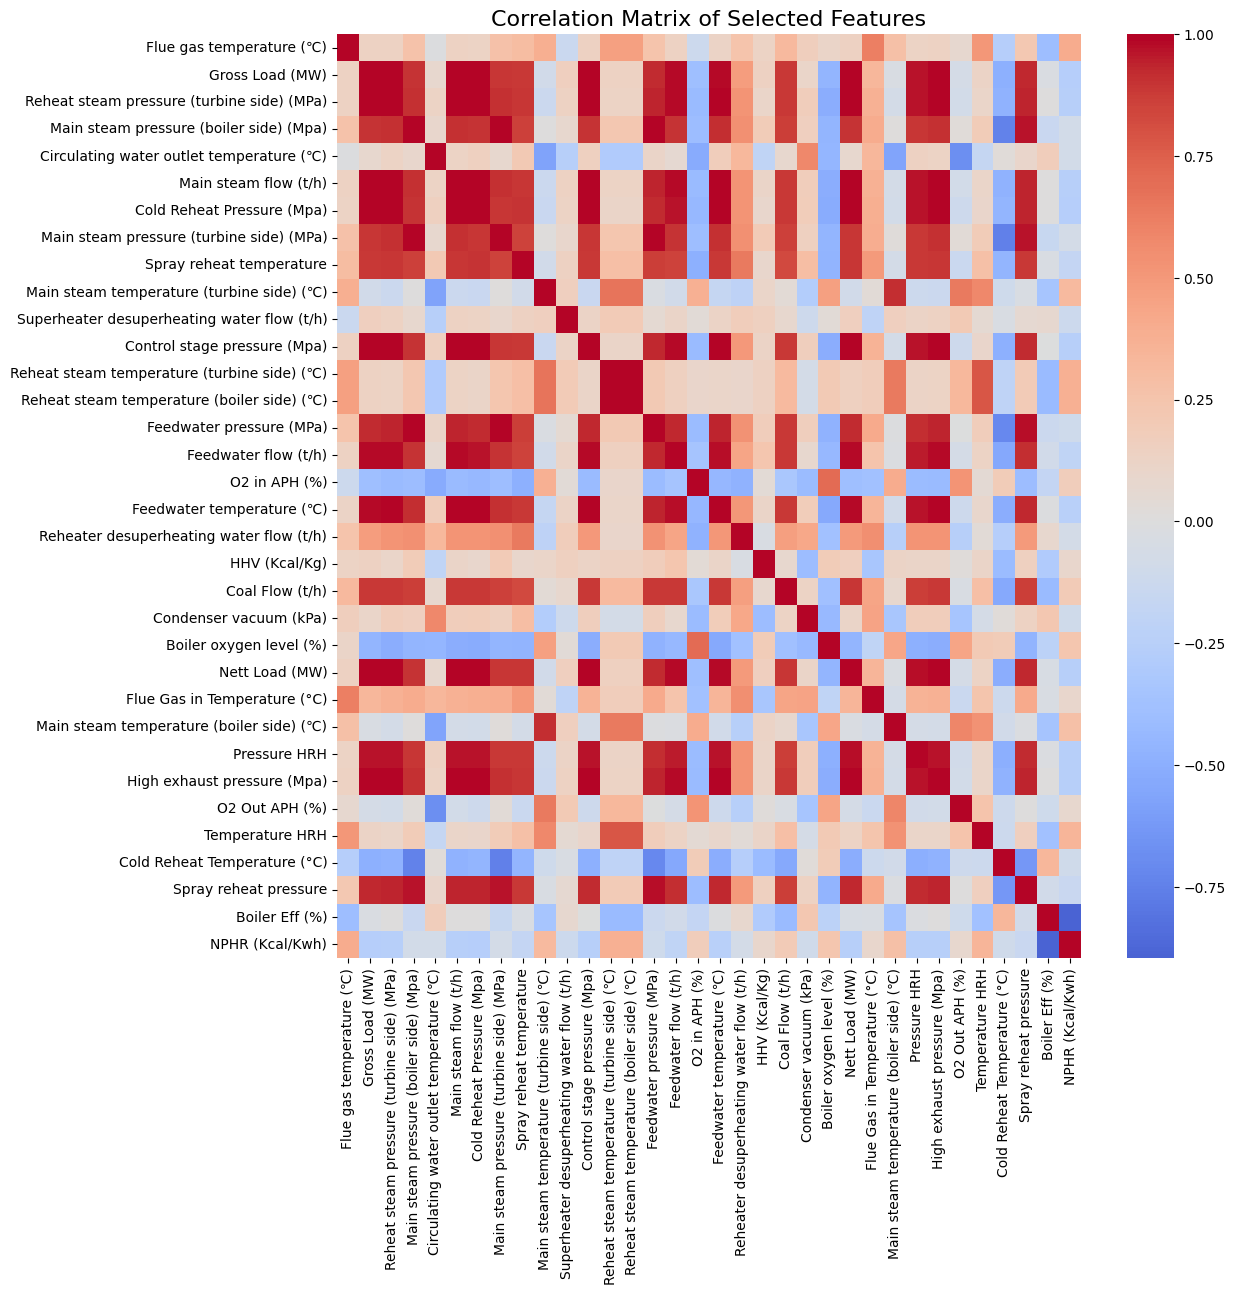

In [28]:
# --- 1. Jalankan Perhitungan Korelasi ---
corr_matrix = numeric_df[final_inputs + ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']].corr()

# 4. Visualisasi dengan Heatmap untuk melihat perbedaan
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Selected Features', fontsize=16)
plt.show()

Total kandidat fitur: 32
---
Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): 14
Daftar: ['Main steam pressure (boiler side) (Mpa)', 'Circulating water outlet temperature (℃)', 'Main steam pressure (turbine side) (MPa)', 'Main steam temperature (turbine side) (℃)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Feedwater pressure (MPa)', 'HHV (Kcal/Kg)', 'Coal Flow (t/h)', 'Condenser vacuum (kPa)', 'Main steam temperature (boiler side) (℃)', 'O2 Out APH (%)', 'Temperature HRH', 'Cold Reheat Temperature (°C)']

Fitur terpilih untuk NPHR (Hubungan Terkuat): 18
Daftar: ['Flue gas temperature (℃)', 'Gross Load (MW)', 'Reheat steam pressure (turbine side) (MPa)', 'Main steam flow (t/h)', 'Cold Reheat Pressure (Mpa)', 'Spray reheat temperature', 'Superheater desuperheating water flow (t/h)', 'Control stage pressure (Mpa)', 'Feedwater flow (t/h)', 'O2 in APH (%)', 'Feedwater temperature (℃)', 'Reheater desuperheating water flow (t/h)', 'Boiler

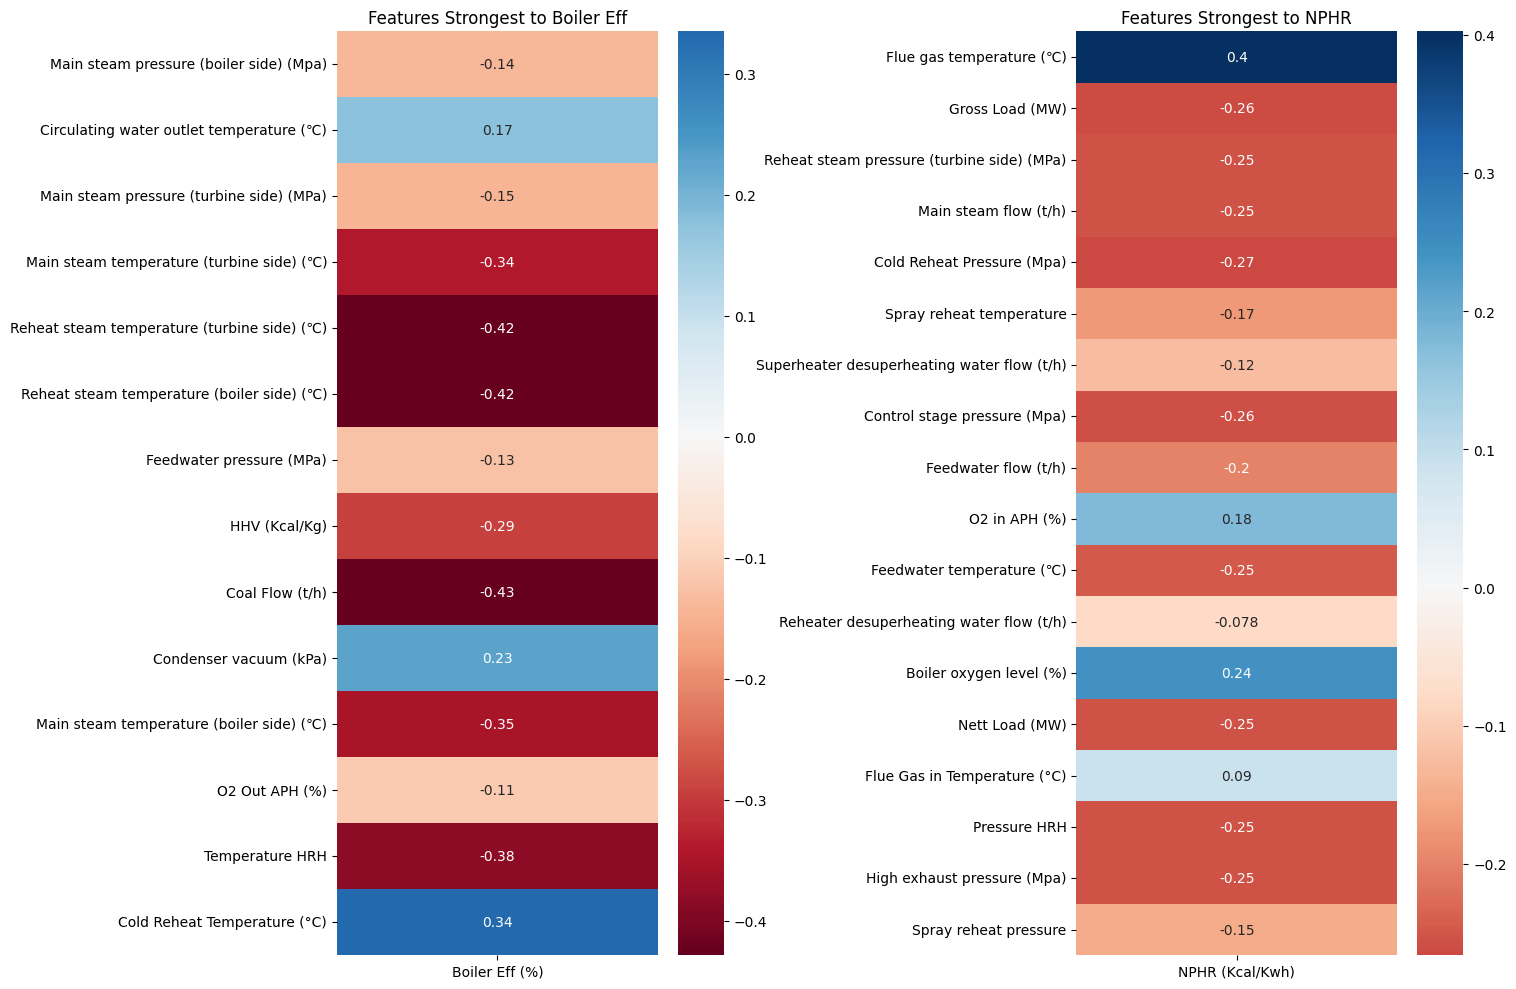

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Persiapan Data ---
candidates = [f for f in final_inputs if f not in ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']]
targets = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# Hitung korelasi
corr_matrix = df[candidates + targets].corr()

# --- 2. Pemisahan Berdasarkan Korelasi Tertinggi (Tanpa Threshold) ---
inputs_for_boiler = []
inputs_for_nphr = []

for feature in candidates:
    corr_to_boiler = abs(corr_matrix.loc[feature, 'Boiler Eff (%)'])
    corr_to_nphr = abs(corr_matrix.loc[feature, 'NPHR (Kcal/Kwh)'])
    
    # Bandingkan mana yang lebih kuat
    if corr_to_boiler > corr_to_nphr:
        inputs_for_boiler.append(feature)
    else:
        inputs_for_nphr.append(feature)

# --- 3. Print Hasil ---
print(f"Total kandidat fitur: {len(candidates)}")
print(f"---")
print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
print(f"Daftar: {inputs_for_boiler}\n")
print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
print(f"Daftar: {inputs_for_nphr}")

# --- 4. Visualisasi Perbandingan ---
# Kita visualisasikan fitur Boiler Eff dan NPHR secara terpisah untuk melihat kontrasnya
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

# Heatmap untuk Boiler Eff Features
if inputs_for_boiler:
    sns.heatmap(corr_matrix.loc[inputs_for_boiler, ['Boiler Eff (%)']], 
                annot=True, cmap='RdBu', center=0, ax=ax[0])
    ax[0].set_title('Features Strongest to Boiler Eff')

# Heatmap untuk NPHR Features
if inputs_for_nphr:
    sns.heatmap(corr_matrix.loc[inputs_for_nphr, ['NPHR (Kcal/Kwh)']], 
                annot=True, cmap='RdBu', center=0, ax=ax[1])
    ax[1].set_title('Features Strongest to NPHR')

plt.tight_layout()
plt.show()

In [30]:
print(f"Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): {len(inputs_for_boiler)}")
inputs_for_boiler

Fitur terpilih untuk Boiler Eff (Hubungan Terkuat): 14


['Main steam pressure (boiler side) (Mpa)',
 'Circulating water outlet temperature (℃)',
 'Main steam pressure (turbine side) (MPa)',
 'Main steam temperature (turbine side) (℃)',
 'Reheat steam temperature (turbine side) (℃)',
 'Reheat steam temperature (boiler side) (℃)',
 'Feedwater pressure (MPa)',
 'HHV (Kcal/Kg)',
 'Coal Flow (t/h)',
 'Condenser vacuum (kPa)',
 'Main steam temperature (boiler side) (℃)',
 'O2 Out APH (%)',
 'Temperature HRH',
 'Cold Reheat Temperature (°C)']

In [31]:
print(f"Fitur terpilih untuk NPHR (Hubungan Terkuat): {len(inputs_for_nphr)}")
inputs_for_nphr

Fitur terpilih untuk NPHR (Hubungan Terkuat): 18


['Flue gas temperature (℃)',
 'Gross Load (MW)',
 'Reheat steam pressure (turbine side) (MPa)',
 'Main steam flow (t/h)',
 'Cold Reheat Pressure (Mpa)',
 'Spray reheat temperature',
 'Superheater desuperheating water flow (t/h)',
 'Control stage pressure (Mpa)',
 'Feedwater flow (t/h)',
 'O2 in APH (%)',
 'Feedwater temperature (℃)',
 'Reheater desuperheating water flow (t/h)',
 'Boiler oxygen level (%)',
 'Nett Load (MW)',
 'Flue Gas in Temperature (°C)',
 'Pressure HRH',
 'High exhaust pressure (Mpa)',
 'Spray reheat pressure']

In [36]:
import pandas as pd


# Load your dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

In [37]:
# 2. Definisikan daftar fitur input yang Anda inginkan
selected_inputs = [
    'Main steam temperature (boiler side) (℃)', 
    'Temperature HRH', 
    'O2 Out APH (%)', 
    'Reheat steam temperature (boiler side) (℃)', 
    'Coal Flow (t/h)', 
    'Reheat steam temperature (turbine side) (℃)', 
    'Main steam pressure (boiler side) (Mpa)', 
    'Main steam pressure (turbine side) (MPa)', 
    'HHV (Kcal/Kg)', 
    'Condenser vacuum (kPa)', 
    'Circulating water outlet temperature (℃)', 
    'Feedwater pressure (MPa)', 
    'Main steam temperature (turbine side) (℃)', 
    'Cold Reheat Temperature (°C)'
]

# --- PROSES UNTUK BOILER EFFICIENCY ---
# Mengambil fitur input + Target Boiler
cols_boiler = selected_inputs + ['Boiler Eff (%)']
# Gunakan intersection untuk memastikan kolom benar-benar ada di df
df_boiler_final = df[df.columns.intersection(cols_boiler)].copy()

# Simpan ke Excel
df_boiler_final.to_excel('Rev Selected_Features_Boiler_Efficiency Dataset 1.xlsx', index=False)
print("File 'Rev Selected_Features_Boiler_Efficiency Dataset 1.xlsx' berhasil disimpan.")
print(f"Jumlah kolom yang berhasil diekstrak: {len(df_boiler_final.columns)}")

File 'Rev Selected_Features_Boiler_Efficiency Dataset 1.xlsx' berhasil disimpan.
Jumlah kolom yang berhasil diekstrak: 15


In [38]:
import pandas as pd


# Load your dataset
df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# Drop non-numerical columns (IDs, names, etc.) if any
# df = df.drop(columns=['ID', 'Name'])

In [39]:
# 2. Definisikan daftar fitur input baru sesuai permintaan Anda
selected_inputs_nphr = [
    'Reheater desuperheating water flow (t/h)', 
    'Superheater desuperheating water flow (t/h)', 
    'Spray reheat temperature', 
    'Spray reheat pressure', 
    'Gross Load (MW)', 
    'Flue Gas in Temperature (°C)', 
    'High exhaust pressure (Mpa)', 
    'Cold Reheat Pressure (Mpa)', 
    'Feedwater temperature (℃)', 
    'O2 in APH (%)', 
    'Pressure HRH', 
    'Nett Load (MW)', 
    'Flue gas temperature (℃)', 
    'Main steam flow (t/h)', 
    'Reheat steam pressure (turbine side) (MPa)', 
    'Boiler oxygen level (%)', 
    'Control stage pressure (Mpa)', 
    'Feedwater flow (t/h)'
]

# --- PROSES UNTUK NPHR ---
# Menggabungkan fitur input baru dengan Target NPHR
cols_nphr = selected_inputs_nphr + ['NPHR (Kcal/Kwh)']

# Menggunakan intersection untuk memastikan kolom tersedia di dalam file Excel
df_nphr_final = df[df.columns.intersection(cols_nphr)].copy()

# Simpan ke Excel dengan nama file yang relevan
output_filename = 'Rev Selected_Features_NPHR Dataset 1.xlsx'
df_nphr_final.to_excel(output_filename, index=False)

print(f"File '{output_filename}' berhasil disimpan.")
print(f"Jumlah kolom yang berhasil diekstrak: {len(df_nphr_final.columns)}")

File 'Rev Selected_Features_NPHR Dataset 1.xlsx' berhasil disimpan.
Jumlah kolom yang berhasil diekstrak: 19


In [ ]:
# # --- 1. Tentukan Fitur yang Signifikan untuk Masing-Masing (EFA + Correlation) ---
# # Kita gunakan threshold kecil (misal 0.2) untuk melihat potensi fitur "Shared"
# threshold_shared = 0.2

# sig_boiler = corr_matrix[abs(corr_matrix['Boiler Eff (%)']) >= threshold_shared].index.tolist()
# sig_nphr = corr_matrix[abs(corr_matrix['NPHR (Kcal/Kwh)']) >= threshold_shared].index.tolist()

# # Bersihkan dari target itu sendiri
# sig_boiler = [f for f in sig_boiler if f not in targets]
# sig_nphr = [f for f in sig_nphr if f not in targets]

# # --- 2. Cari Irisan (Intersection) ---
# shared_features = list(set(sig_boiler) & set(sig_nphr))
# only_boiler = list(set(sig_boiler) - set(sig_nphr))
# only_nphr = list(set(sig_nphr) - set(sig_boiler))

# # --- 3. Print Hasil Analisis ---
# print(f"Fitur yang BISA digunakan di KEDUA model: {len(shared_features)}")
# print(f"Daftar Shared: {shared_features}\n")

# print(f"Fitur UNIK untuk Boiler saja: {only_boiler}")
# print(f"Fitur UNIK untuk NPHR saja: {only_nphr}")

# # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if shared_features:
#     sns.heatmap(corr_matrix.loc[shared_features, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Shared Features: Correlation Strength to Both Targets')
#     plt.show()
#     shared_features

#         # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if only_boiler:
#     sns.heatmap(corr_matrix.loc[only_boiler, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Unique Features for Boiler: Correlation Strength to Both Targets')
#     plt.show()
#     only_boiler

#         # --- 4. Visualisasi Venn Diagram Sederhana via Heatmap ---
# plt.figure(figsize=(10, 6))
# if only_nphr:
#     sns.heatmap(corr_matrix.loc[only_nphr, targets], annot=True, cmap='RdBu', center=0)
#     plt.title('Unique Features for NPHR: Correlation Strength to Both Targets')
#     plt.show()
#     only_nphr



In [ ]:
# print ('Fitur Terpilih Untuk Boiler Efficiency')
# shared_features,only_boiler

In [ ]:
# print ('Fitur Terpilih Untuk NPHR')
# shared_features,only_nphr

In [ ]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant
# from sklearn.preprocessing import StandardScaler

# def calculate_vif_scaled(data_frame, feature_list):
#     """
#     Menghitung VIF setelah melakukan Standard Scaling untuk stabilitas numerik.
#     """
#     if not feature_list:
#         return pd.DataFrame(columns=["Feature", "VIF"])
        
#     # 1. Ambil data dan bersihkan NaN
#     X = data_frame[feature_list].copy().dropna()
    
#     if X.empty:
#         return "Dataset kosong setelah dropna()."

#     # 2. Standard Scaling
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
    
#     # 3. Buat DataFrame baru dari hasil scaling
#     X_scaled_df = pd.DataFrame(X_scaled, columns=feature_list)
    
#     # 4. Tambahkan konstanta (Intersept)
#     X_scaled_df = add_constant(X_scaled_df)
    
#     # 5. Hitung VIF
#     vif_data = pd.DataFrame()
#     vif_data["Feature"] = X_scaled_df.columns
    
#     vif_list = []
#     for i in range(len(X_scaled_df.columns)):
#         try:
#             vif = variance_inflation_factor(X_scaled_df.values, i)
#         except:
#             vif = float('inf')
#         vif_list.append(vif)
        
#     vif_data["VIF"] = vif_list
    
#     # Menghapus baris 'const' dan urutkan
#     return vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

# # --- 1. Gabungkan fitur untuk masing-masing model ---
# final_inputs_boiler = list(set(shared_features + only_boiler))
# final_inputs_nphr = list(set(shared_features + only_nphr))

# # --- 2. Hitung VIF untuk Model Boiler ---
# print("=== VIF Analysis: Boiler Efficiency Model (Scaled) ===")
# vif_boiler = calculate_vif_scaled(df, final_inputs_boiler)
# print(vif_boiler)
# print("\n")

# # --- 3. Hitung VIF untuk Model NPHR ---
# print("=== VIF Analysis: NPHR Model (Scaled) ===")
# vif_nphr = calculate_vif_scaled(df, final_inputs_nphr)
# print(vif_nphr)

# # --- 4. Visualisasi VIF (Boiler) ---
# plt.figure(figsize=(10, 6))
# # Gunakan log scale jika ada nilai INF agar plot tidak hancur
# sns.barplot(x='VIF', y='Feature', data=vif_boiler.replace(float('inf'), 100), palette='viridis')
# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.title('VIF Scores for Boiler Efficiency (Values > 100 clipped for viz)')
# plt.legend()
# plt.show()

# # --- 5. Visualisasi VIF (NPHR) ---
# plt.figure(figsize=(10, 6))
# sns.barplot(x='VIF', y='Feature', data=vif_nphr.replace(float('inf'), 100), palette='magma')
# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.title('VIF Scores for NPHR (Values > 100 clipped for viz)')
# plt.legend()
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant

# def auto_clean_vif(data_frame, feature_list, threshold=10.0):
#     """
#     Calculates VIF and removes the feature with the highest VIF one by one
#     until all features have a VIF < threshold.
#     """
#     # 1. Prepare data (Drop NaNs)
#     X = data_frame[feature_list].copy().dropna()
    
#     while True:
#         # Add constant for VIF calculation
#         X_const = add_constant(X)
#         vif_list = []
#         for i in range(len(X_const.columns)):
#             try:
#                 # Use scalar divide handling to prevent crashes on 'inf'
#                 vif = variance_inflation_factor(X_const.values, i)
#             except:
#                 vif = float('inf')
#             vif_list.append(vif)
            
#         vif_df = pd.DataFrame({'Feature': X_const.columns, 'VIF': vif_list})
#         vif_df = vif_df[vif_df['Feature'] != 'const']
        
#         max_vif = vif_df['VIF'].max()
        
#         # If the highest VIF is still above threshold, drop that feature
#         if max_vif > threshold or np.isinf(max_vif):
#             feature_to_drop = vif_df.sort_values('VIF', ascending=False)['Feature'].iloc[0]
#             print(f"Removing '{feature_to_drop}' (VIF: {max_vif:.2f})")
#             X = X.drop(columns=[feature_to_drop])
#         else:
#             break
            
#     return X.columns.tolist(), vif_df

# # --- EKSEKUSI PEMBERSIHAN ---

# print("=== Cleaning Boiler Model Features ===")
# refined_boiler_features, final_vif_boiler = auto_clean_vif(df, final_inputs_boiler)

# # Tampilkan Hasil Akhir Boiler
# print("\n--- HASIL AKHIR VIF: BOILER EFFICIENCY MODEL ---")
# print(final_vif_boiler.sort_values(by="VIF", ascending=False).reset_index(drop=True))

# print("\n" + "="*50 + "\n")

# print("=== Cleaning NPHR Model Features ===")
# refined_nphr_features, final_vif_nphr = auto_clean_vif(df, final_inputs_nphr)

# # Tampilkan Hasil Akhir NPHR
# print("\n--- HASIL AKHIR VIF: NPHR MODEL ---")
# print(final_vif_nphr.sort_values(by="VIF", ascending=False).reset_index(drop=True))

In [ ]:
# # --- 4. Visualisasi VIF (Boiler) ---
# plt.figure(figsize=(10, 6))

# # Pastikan data diurutkan agar grafik mudah dibaca
# vif_boiler_sorted = final_vif_boiler.sort_values(by='VIF', ascending=False)

# # Menggunakan 'hue' untuk menghindari FutureWarning
# sns.barplot(
#     x='VIF', 
#     y='Feature', 
#     data=vif_boiler_sorted, 
#     hue='Feature', 
#     palette='viridis', 
#     legend=False
# )

# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
# plt.title('Final VIF Scores: Boiler Efficiency Model', fontsize=14)
# plt.xlabel('VIF Value')
# plt.ylabel('Selected Features')
# plt.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()

# # --- 5. Visualisasi VIF (NPHR) ---
# plt.figure(figsize=(10, 6))

# # Pastikan data diurutkan
# vif_nphr_sorted = final_vif_nphr.sort_values(by='VIF', ascending=False)

# sns.barplot(
#     x='VIF', 
#     y='Feature', 
#     data=vif_nphr_sorted, 
#     hue='Feature', 
#     palette='magma', 
#     legend=False
# )

# plt.axvline(x=10, color='red', linestyle='--', label='Danger Threshold (10)')
# plt.axvline(x=5, color='orange', linestyle=':', label='Ideal Threshold (5)')
# plt.title('Final VIF Scores: NPHR Model', fontsize=14)
# plt.xlabel('VIF Value')
# plt.ylabel('Selected Features')
# plt.legend()
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.show()

In [ ]:
# # --- PENYIMPANAN DATASET FINAL BOILER ---
# # 1. Gabungkan fitur input hasil VIF dengan Target Boiler
# boiler_final_columns = refined_boiler_features + ['Boiler Eff (%)']
# # 2. Filter dataframe asli menggunakan intersection untuk keamanan
# df_final_boiler = df[df.columns.intersection(boiler_final_columns)].copy()

# # Simpan ke Excel
# df_final_boiler.to_excel('#2 final feature selected dataset 1 for boiler efficiency.xlsx', index=False)
# print(f"Berhasil menyimpan {len(df_final_boiler.columns)} kolom ke file Boiler.")

# # --- PENYIMPANAN DATASET FINAL NPHR ---
# # 1. Gabungkan fitur input hasil VIF dengan Target NPHR
# nphr_final_columns = refined_nphr_features + ['NPHR (Kcal/Kwh)']
# # 2. Filter dataframe asli
# df_final_nphr = df[df.columns.intersection(nphr_final_columns)].copy()

# # Simpan ke Excel
# df_final_nphr.to_excel('#2 final feature selected dataset 1 for nphr.xlsx', index=False)
# print(f"Berhasil menyimpan {len(df_final_nphr.columns)} kolom ke file NPHR.")

# # --- VALIDASI AKHIR ---
# print("\nRingkasan Kolom:")
# print(f"Boiler Features: {df_final_boiler.columns.tolist()}")
# print(f"NPHR Features: {df_final_nphr.columns.tolist()}")

In [ ]:
# import pandas as pd


# # Load your dataset
# df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# # Drop non-numerical columns (IDs, names, etc.) if any
# # df = df.drop(columns=['ID', 'Name'])

In [ ]:
# # Daftar fitur input (Hanya yang unik/tidak ada duplikat persis)
# selected_inputs = [
#     'Main steam temperature (boiler side) (℃)', 
#     'Temperature HRH', 
#     'O2 Out APH (%)', 
#     'Reheat steam temperature (boiler side) (℃)', 
#     'Coal Flow (t/h)', 
#     'Reheat steam temperature (turbine side) (℃)', 
#     'Main steam pressure (boiler side) (Mpa)', 
#     'Main steam pressure (turbine side) (MPa)', 
#     'HHV (Kcal/Kg)', 
#     'Condenser vacuum (kPa)', 
#     'Circulating water outlet temperature (℃)', 
#     'Feedwater pressure (MPa)', 
#     'Main steam temperature (turbine side) (℃)', 
#     'Cold Reheat Temperature (°C)', # Menambahkan koma yang hilang di sini
#     'Reheater desuperheating water flow (t/h)', 
#     'Superheater desuperheating water flow (t/h)', 
#     'Spray reheat temperature', 
#     'Spray reheat pressure', 
#     'Gross Load (MW)', 
#     'Flue Gas in Temperature (°C)', 
#     'High exhaust pressure (Mpa)', 
#     'Cold Reheat Pressure (Mpa)', 
#     'Feedwater temperature (℃)', 
#     'O2 in APH (%)', 
#     'Pressure HRH', 
#     'Nett Load (MW)', 
#     'Flue gas temperature (℃)', 
#     'Main steam flow (t/h)', 
#     'Reheat steam pressure (turbine side) (MPa)', 
#     'Boiler oxygen level (%)', 
#     'Control stage pressure (Mpa)', 
#     'Feedwater flow (t/h)'
# ]

# # --- PROSES UNTUK BOILER EFFICIENCY ---
# # Mengambil fitur input + Target Boiler
# cols_boiler = selected_inputs + ['Boiler Eff (%)']
# # Gunakan intersection untuk memastikan kolom benar-benar ada di df
# df_boiler_final = df[df.columns.intersection(cols_boiler)].copy()

# # Simpan ke Excel
# df_boiler_final.to_excel('Rev 2 Selected_Features_Boiler_Efficiency Dataset 1.xlsx', index=False)
# print("File 'Rev 2 Selected_Features_Boiler_Efficiency Dataset 1.xlsx' berhasil disimpan.")

In [ ]:
# import pandas as pd


# # Load your dataset
# df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# # Drop non-numerical columns (IDs, names, etc.) if any
# # df = df.drop(columns=['ID', 'Name'])

In [ ]:
# # Daftar fitur input (Hanya yang unik/tidak ada duplikat persis)
# selected_inputs_nphr = [
#     'Main steam temperature (boiler side) (℃)', 
#     'Temperature HRH', 
#     'O2 Out APH (%)', 
#     'Reheat steam temperature (boiler side) (℃)', 
#     'Coal Flow (t/h)', 
#     'Reheat steam temperature (turbine side) (℃)', 
#     'Main steam pressure (boiler side) (Mpa)', 
#     'Main steam pressure (turbine side) (MPa)', 
#     'HHV (Kcal/Kg)', 
#     'Condenser vacuum (kPa)', 
#     'Circulating water outlet temperature (℃)', 
#     'Feedwater pressure (MPa)', 
#     'Main steam temperature (turbine side) (℃)', 
#     'Cold Reheat Temperature (°C)', # Menambahkan koma yang hilang di sini
#     'Reheater desuperheating water flow (t/h)', 
#     'Superheater desuperheating water flow (t/h)', 
#     'Spray reheat temperature', 
#     'Spray reheat pressure', 
#     'Gross Load (MW)', 
#     'Flue Gas in Temperature (°C)', 
#     'High exhaust pressure (Mpa)', 
#     'Cold Reheat Pressure (Mpa)', 
#     'Feedwater temperature (℃)', 
#     'O2 in APH (%)', 
#     'Pressure HRH', 
#     'Nett Load (MW)', 
#     'Flue gas temperature (℃)', 
#     'Main steam flow (t/h)', 
#     'Reheat steam pressure (turbine side) (MPa)', 
#     'Boiler oxygen level (%)', 
#     'Control stage pressure (Mpa)', 
#     'Feedwater flow (t/h)'
# ]

# # --- PROSES UNTUK NPHR ---
# # Menggabungkan fitur input baru dengan Target NPHR
# cols_nphr = selected_inputs_nphr + ['NPHR (Kcal/Kwh)']

# # Menggunakan intersection untuk memastikan kolom tersedia di dalam file Excel
# df_nphr_final = df[df.columns.intersection(cols_nphr)].copy()

# # Simpan ke Excel dengan nama file yang relevan
# output_filename = 'Rev 2 Selected_Features_NPHR Dataset 1.xlsx'
# df_nphr_final.to_excel(output_filename, index=False)

# print(f"File '{output_filename}' berhasil disimpan.")
# print(f"Jumlah kolom yang berhasil diekstrak: {len(df_nphr_final.columns)}")

In [ ]:
# import pandas as pd


# # Load your dataset
# df = pd.read_excel('Cleaned_Dataset 1.xlsx')

# # Drop non-numerical columns (IDs, names, etc.) if any
# # df = df.drop(columns=['ID', 'Name'])

# df